<a href="https://www.kaggle.com/code/omborse771924/e-commerce-sales-performance-98-accuracy?scriptVersionId=342194185" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/e-commerce-sales-performance-analysis/E-Commerce Sales Analytics.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/e-commerce-sales-performance-analysis/E-Commerce Sales Analytics.csv')

In [3]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [4]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


In [5]:
df.info

<bound method DataFrame.info of       order_id order_date  customer_id product_category region  quantity  \
0        10001   1/1/2022         1102           Beauty  South         7   
1        10002   1/2/2022         1435         Clothing  South         7   
2        10003   1/3/2022         1860           Beauty   East         3   
3        10004   1/4/2022         1270      Electronics   West         5   
4        10005   1/5/2022         1106         Clothing   West         5   
...        ...        ...          ...              ...    ...       ...   
4995     14996   9/5/2035         1289         Clothing   West         2   
4996     14997   9/6/2035         1294           Beauty  North         3   
4997     14998   9/7/2035         1450           Beauty   West         3   
4998     14999   9/8/2035         1903      Electronics  South         4   
4999     15000   9/9/2035         1214             Home   East         7   

      unit_price  discount payment_method  delivery_day

In [6]:
df.isnull()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

## EDA

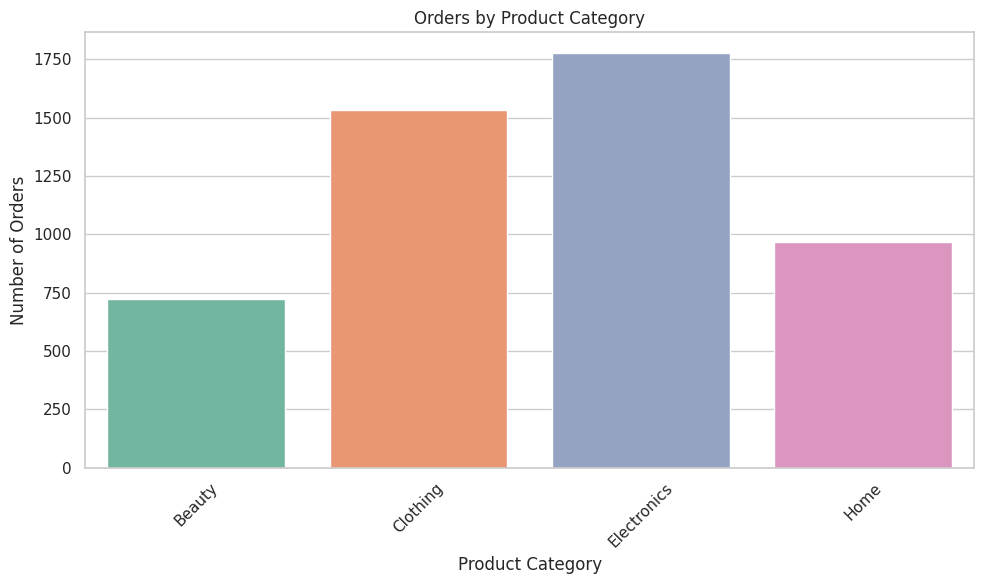

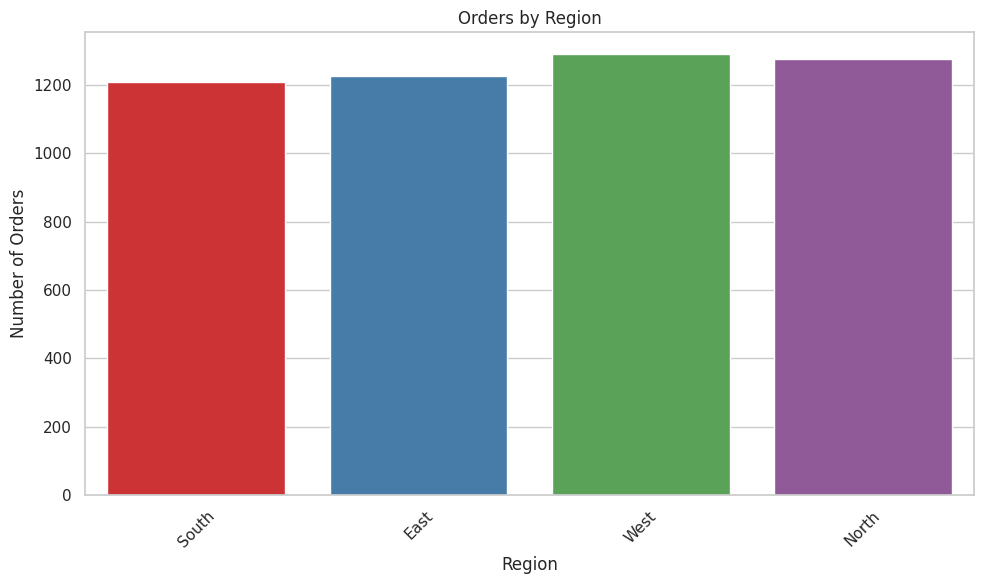

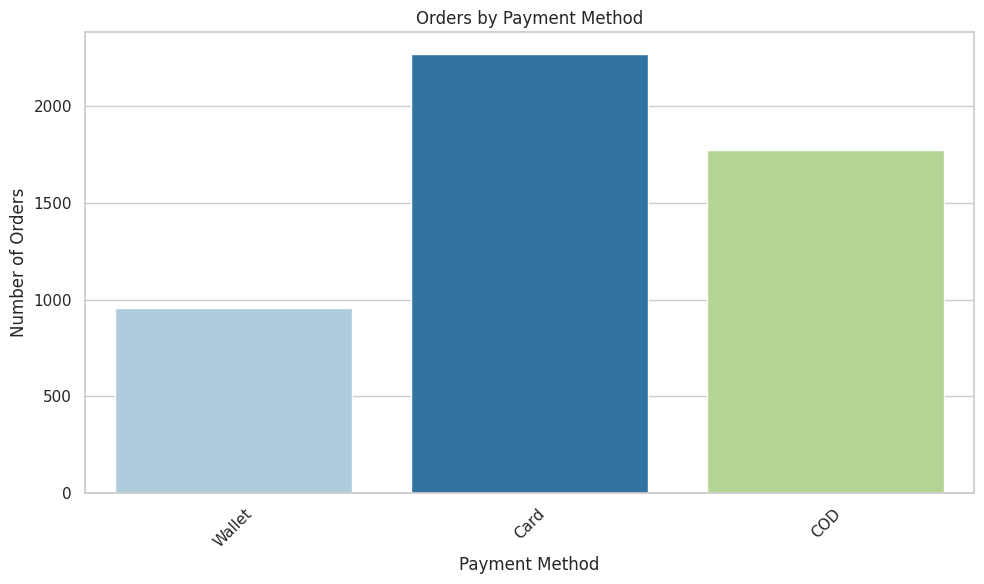

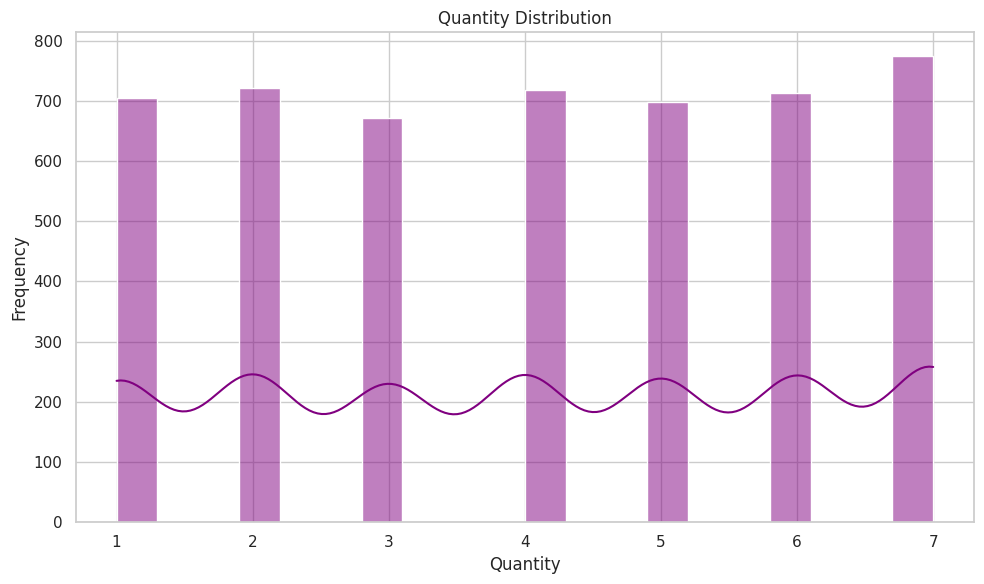

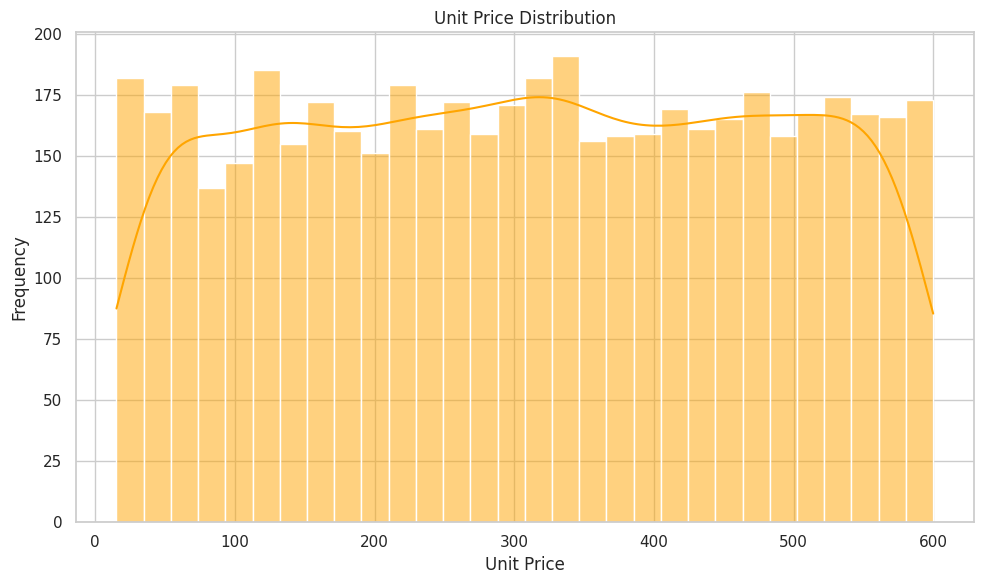

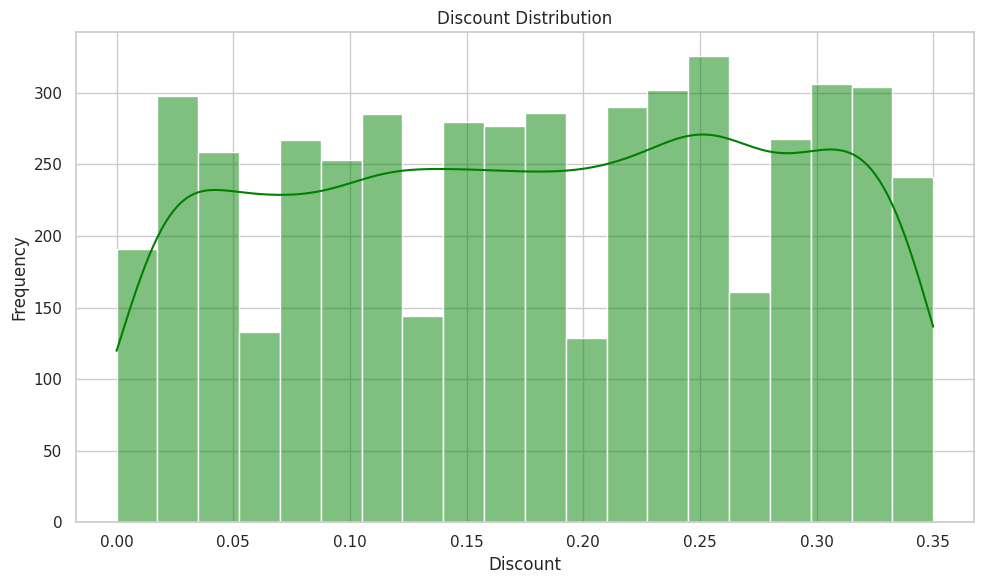

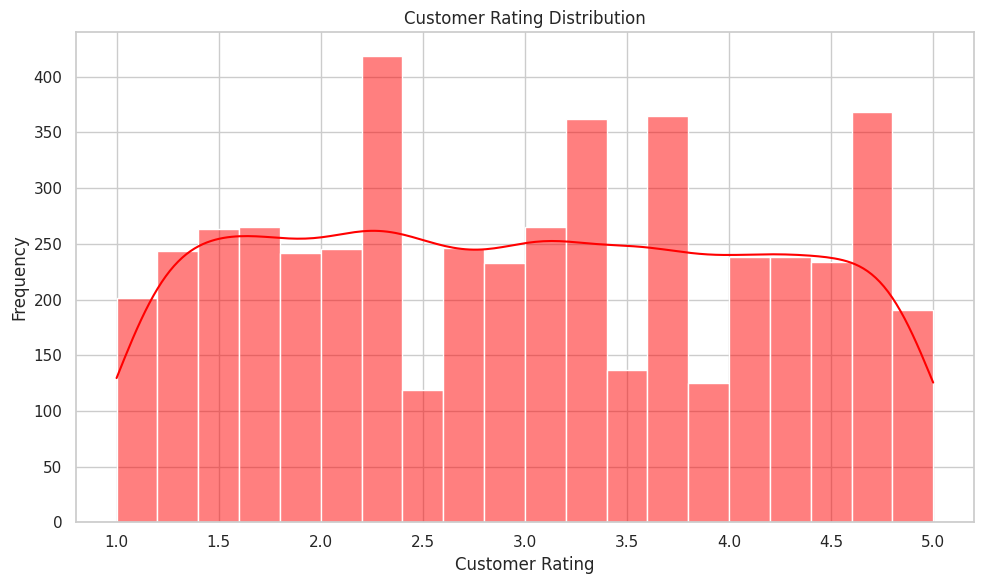

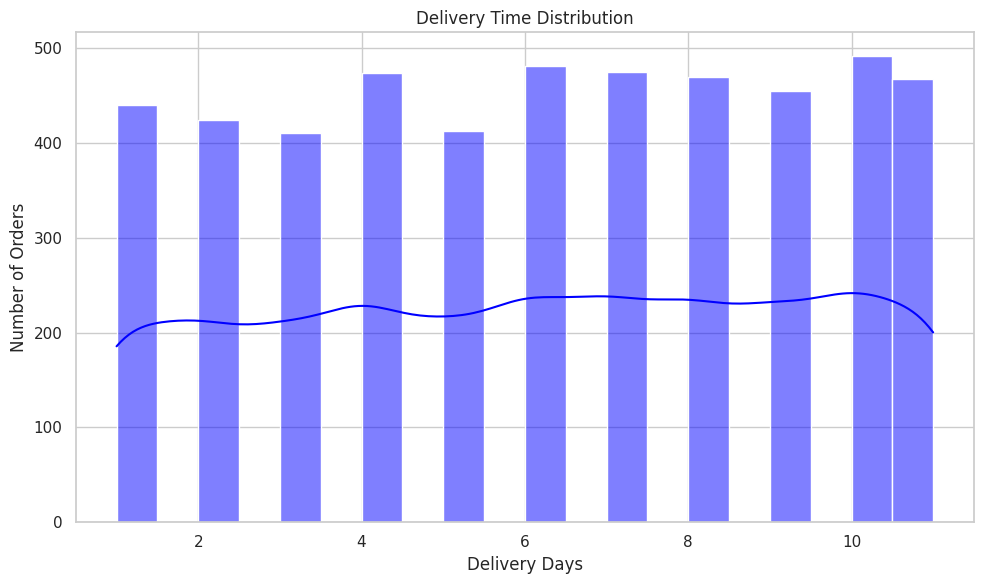

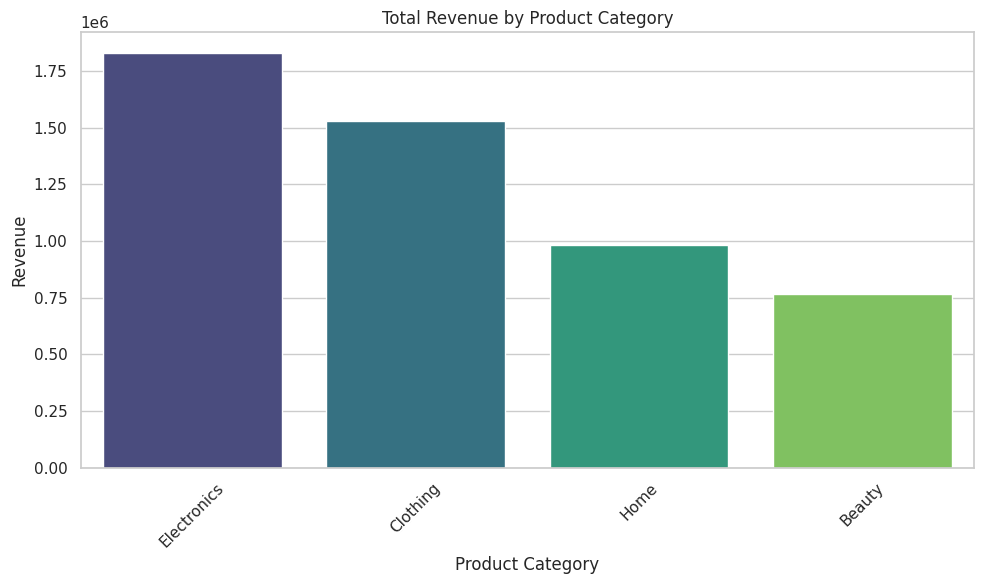

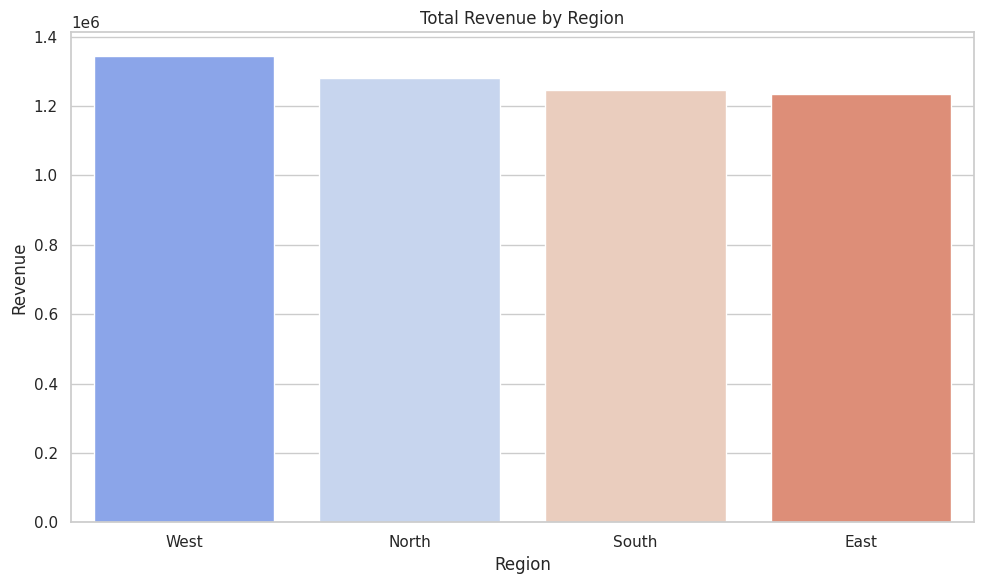

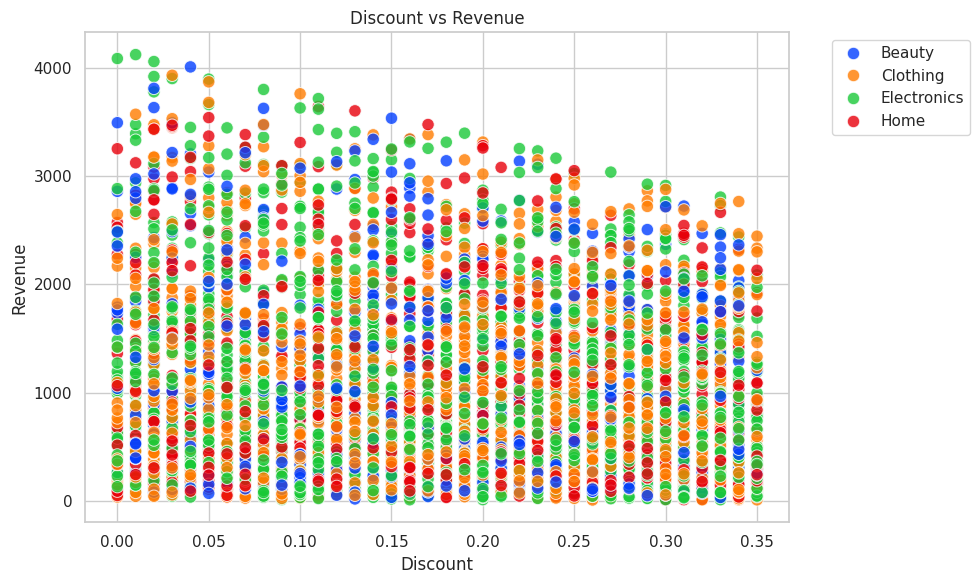

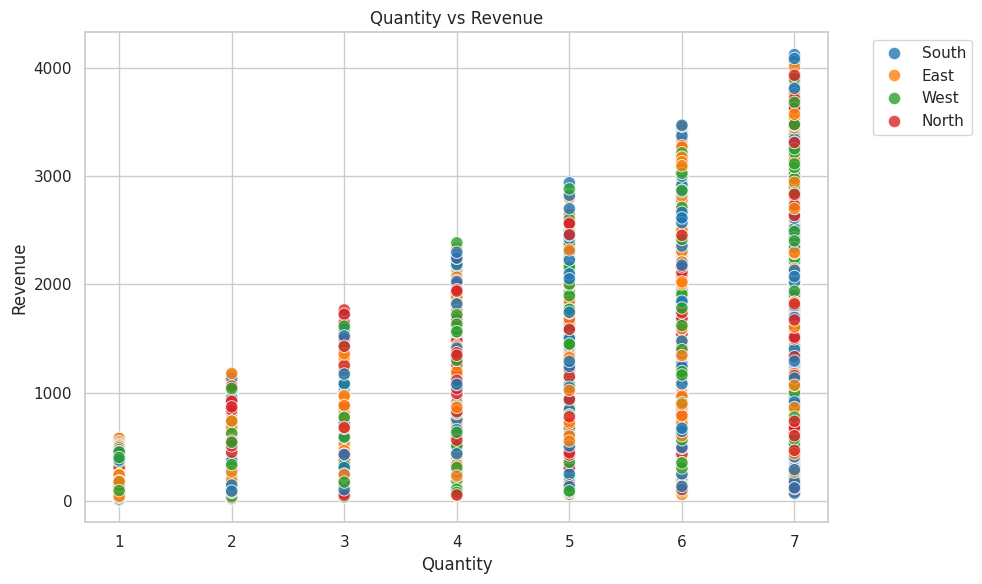

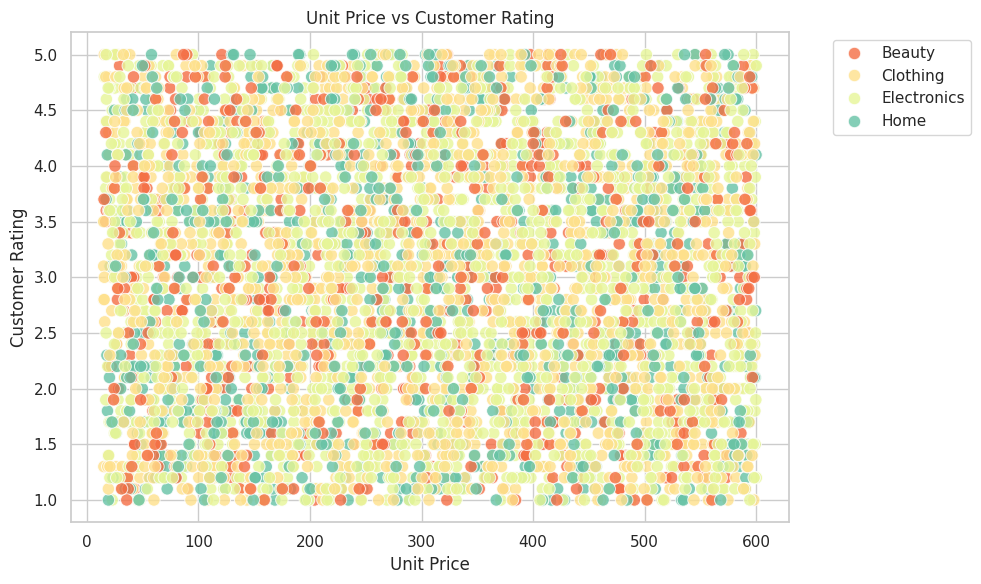

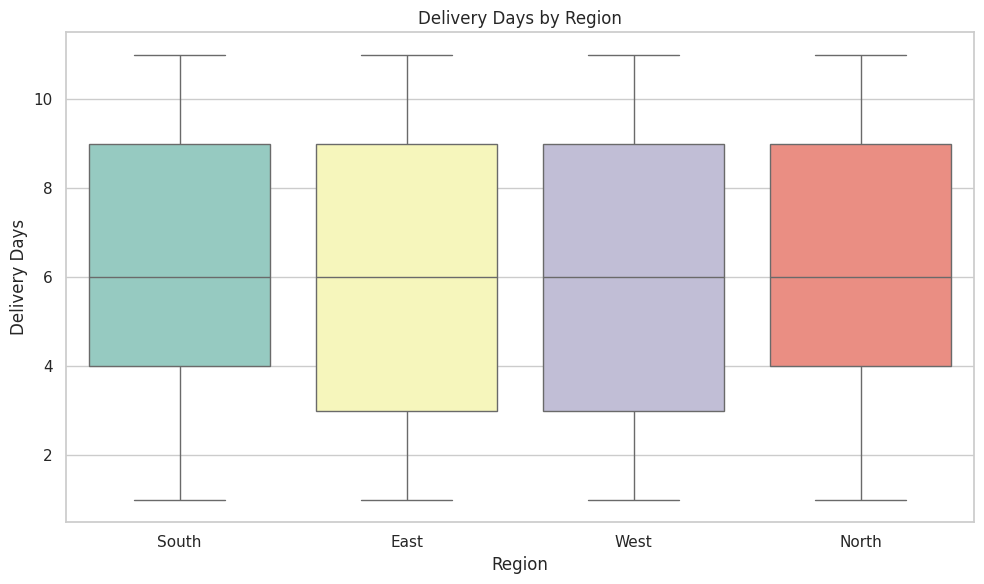

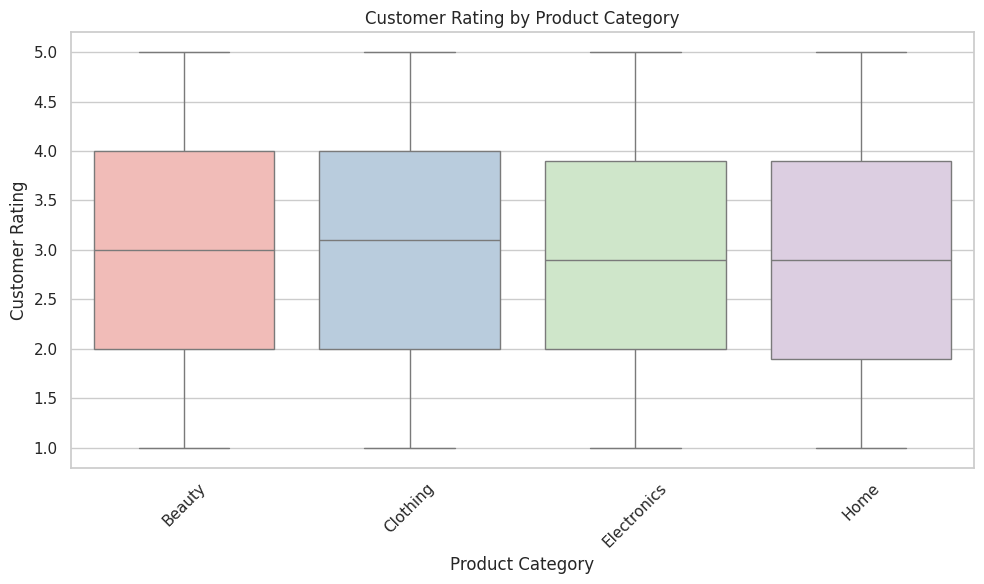

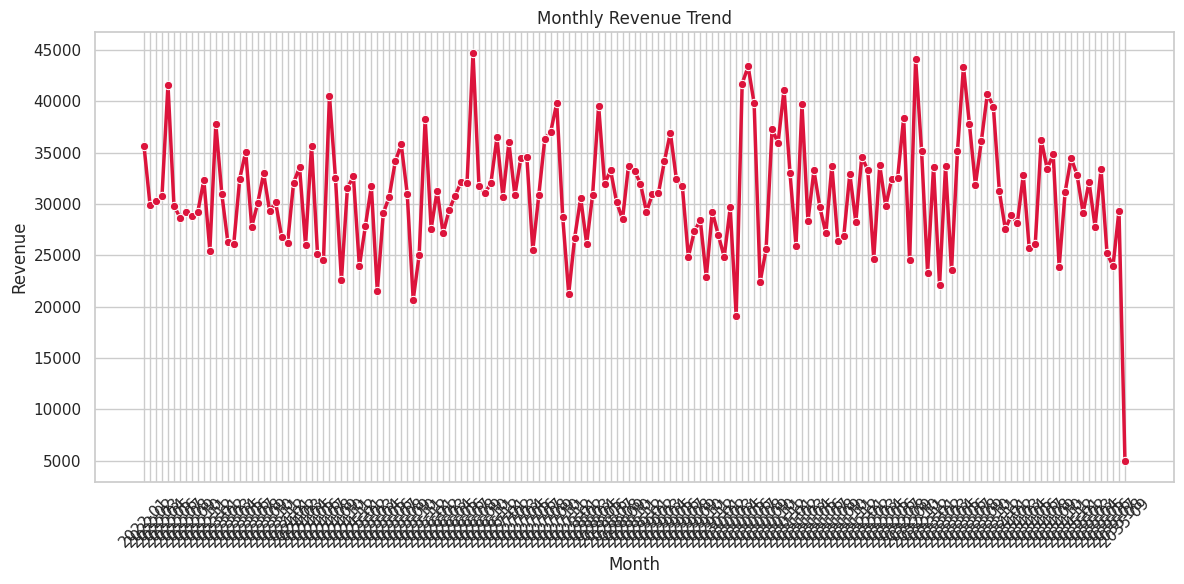

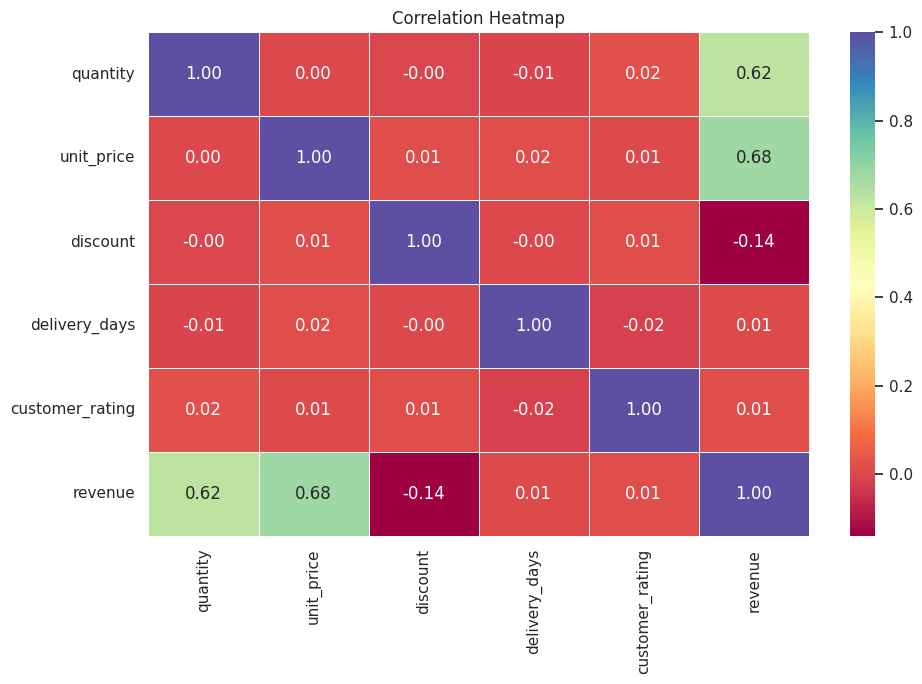

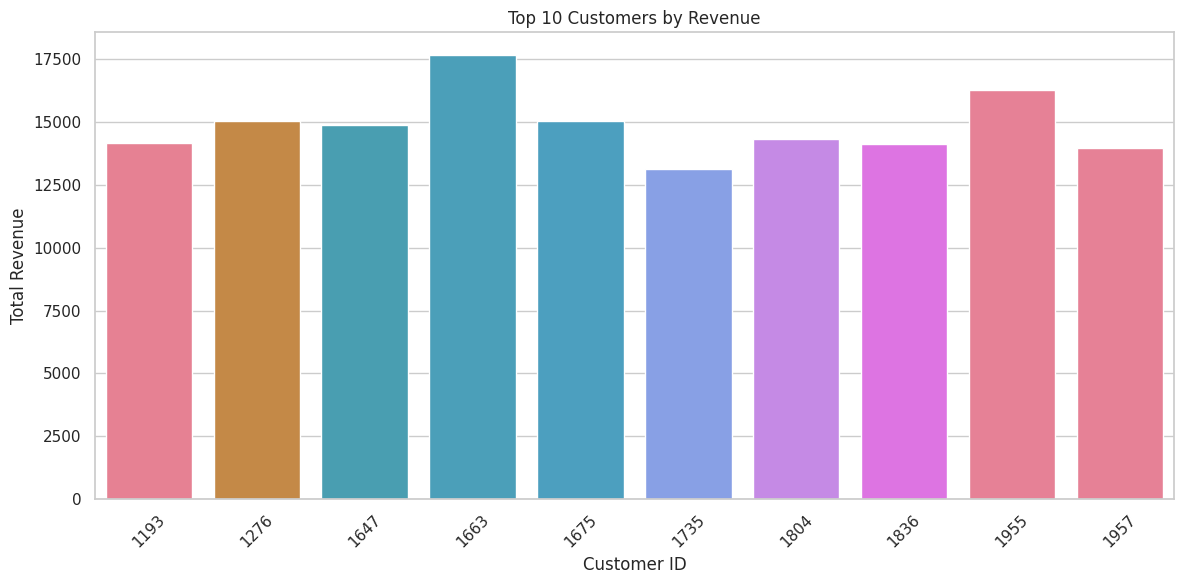

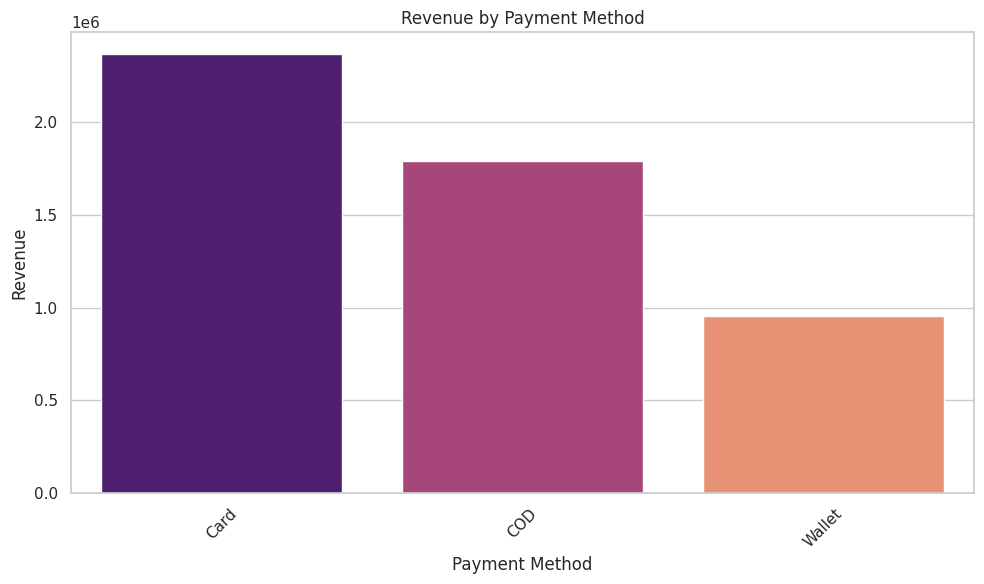

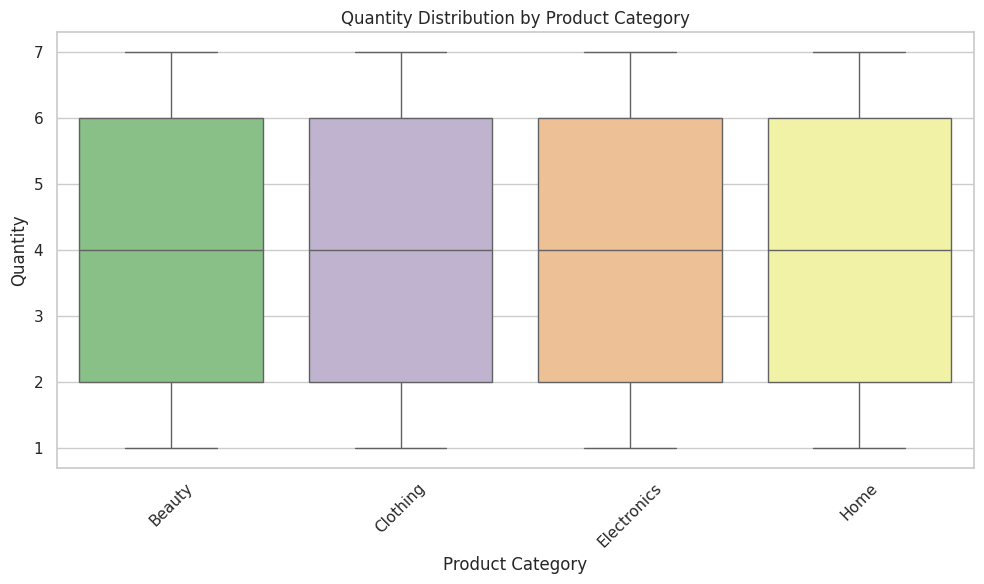

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Colorful theme
sns.set_theme(style="whitegrid", palette="husl")

# =========================================================
# 1. Product Category Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="product_category",
    hue="product_category",
    palette="Set2",
    legend=False
)
plt.title("Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 2. Orders by Region
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="region",
    hue="region",
    palette="Set1",
    legend=False
)
plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 3. Payment Method Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="payment_method",
    hue="payment_method",
    palette="Paired",
    legend=False
)
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 4. Quantity Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="quantity",
    bins=20,
    kde=True,
    color="purple"
)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 5. Unit Price Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="unit_price",
    bins=30,
    kde=True,
    color="orange"
)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 6. Discount Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="discount",
    bins=20,
    kde=True,
    color="green"
)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 7. Customer Rating Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="customer_rating",
    bins=20,
    kde=True,
    color="red"
)
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# =========================================================
# 8. Delivery Days Distribution
# =========================================================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="delivery_days",
    bins=20,
    kde=True,
    color="blue"
)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


# =========================================================
# 9. Revenue by Product Category
# =========================================================
category_revenue = (
    df.groupby("product_category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_revenue,
    x="product_category",
    y="revenue",
    hue="product_category",
    palette="viridis",
    legend=False
)
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 10. Revenue by Region
# =========================================================
region_revenue = (
    df.groupby("region")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=region_revenue,
    x="region",
    y="revenue",
    hue="region",
    palette="coolwarm",
    legend=False
)
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


# =========================================================
# 11. Discount vs Revenue
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="discount",
    y="revenue",
    hue="product_category",
    palette="bright",
    s=80,
    alpha=0.8
)
plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# =========================================================
# 12. Quantity vs Revenue
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="quantity",
    y="revenue",
    hue="region",
    palette="tab10",
    s=80,
    alpha=0.8
)
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# =========================================================
# 13. Unit Price vs Customer Rating
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="unit_price",
    y="customer_rating",
    hue="product_category",
    palette="Spectral",
    s=80,
    alpha=0.8
)
plt.title("Unit Price vs Customer Rating")
plt.xlabel("Unit Price")
plt.ylabel("Customer Rating")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# =========================================================
# 14. Delivery Days by Region
# =========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="region",
    y="delivery_days",
    hue="region",
    palette="Set3",
    legend=False
)
plt.title("Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Delivery Days")
plt.tight_layout()
plt.show()


# =========================================================
# 15. Customer Rating by Product Category
# =========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="product_category",
    y="customer_rating",
    hue="product_category",
    palette="Pastel1",
    legend=False
)
plt.title("Customer Rating by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 16. Revenue Trend Over Time
# =========================================================
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["order_date"] = (
    monthly_revenue["order_date"].astype(str)
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_revenue,
    x="order_date",
    y="revenue",
    marker="o",
    color="crimson",
    linewidth=2.5
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 17. Correlation Heatmap
# =========================================================
numeric_cols = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

plt.figure(figsize=(10, 7))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# =========================================================
# 18. Top Customers by Revenue
# =========================================================
top_customers = (
    df.groupby("customer_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_customers,
    x="customer_id",
    y="revenue",
    hue="customer_id",
    palette="husl",
    legend=False
)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 19. Revenue by Payment Method
# =========================================================
payment_revenue = (
    df.groupby("payment_method")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=payment_revenue,
    x="payment_method",
    y="revenue",
    hue="payment_method",
    palette="magma",
    legend=False
)
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =========================================================
# 20. Quantity by Product Category
# =========================================================
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="product_category",
    y="quantity",
    hue="product_category",
    palette="Accent",
    legend=False
)
plt.title("Quantity Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Features Engineering

Dataset Shape: (5000, 12)

Columns:
Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Feature Engineered Dataset:
   order_id order_date  customer_id product_category region  quantity  \
0     10001 2022-01-01         1102           Beauty  South         7   
1     10002 2022-01-02         1435         Clothing  South         7   
2     10003 2022-01-03         1860           Beauty   East         3   
3     10004 2022-01-04         1270      Electronics   West         5   
4     10005 2022-01-05         1106         Clothing   Wes

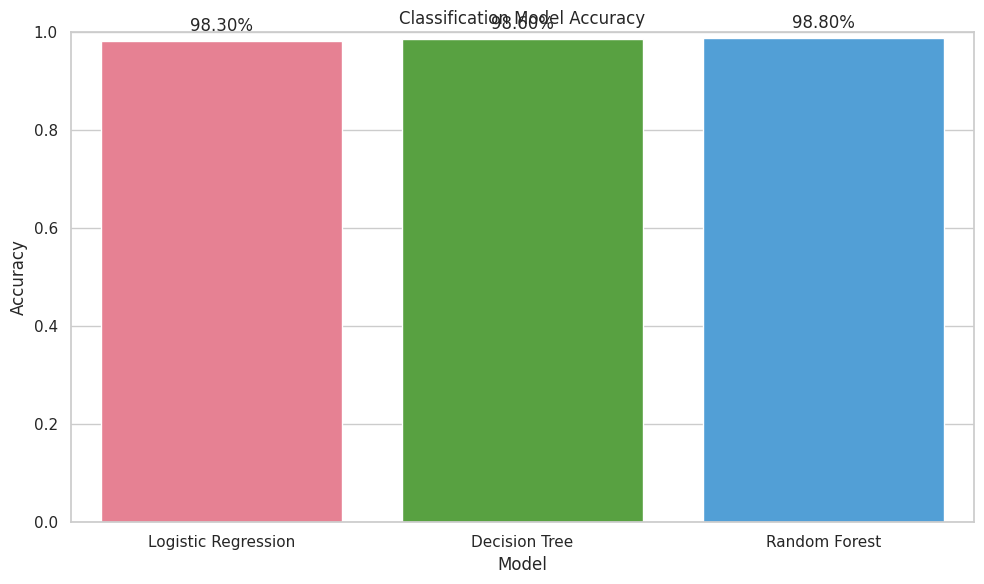

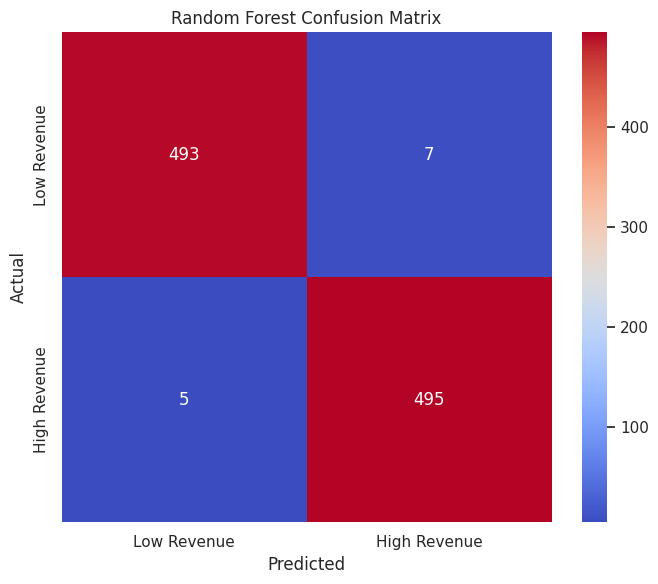

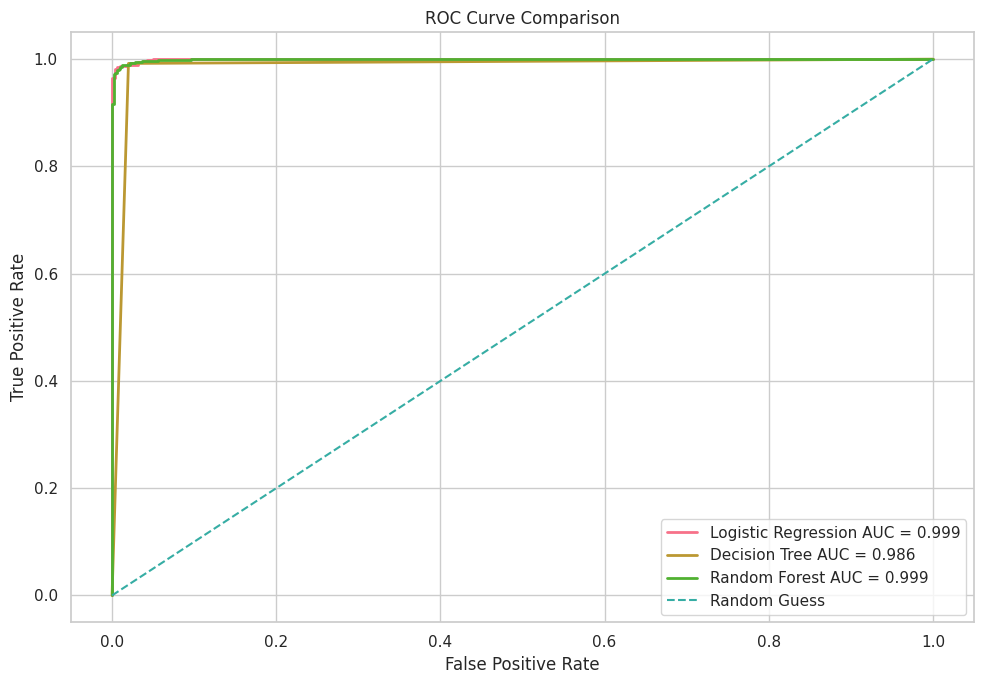


LINEAR REGRESSION
MAE: 219.82
RMSE: 296.54
R2 Score: 0.8695

DECISION TREE REGRESSION
MAE: 60.16
RMSE: 84.57
R2 Score: 0.9894

RANDOM FOREST REGRESSION
MAE: 21.85
RMSE: 32.82
R2 Score: 0.9984

REGRESSION MODEL COMPARISON
                      Model         MAE        RMSE  R2 Score
2  Random Forest Regression   21.849935   32.824638  0.998401
1  Decision Tree Regression   60.163136   84.570075  0.989385
0         Linear Regression  219.824781  296.536612  0.869489


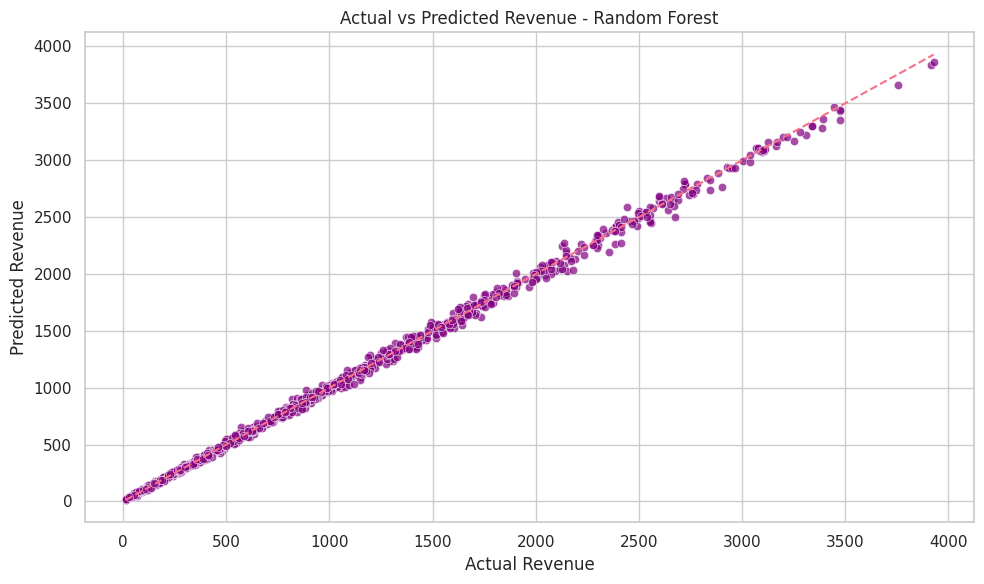

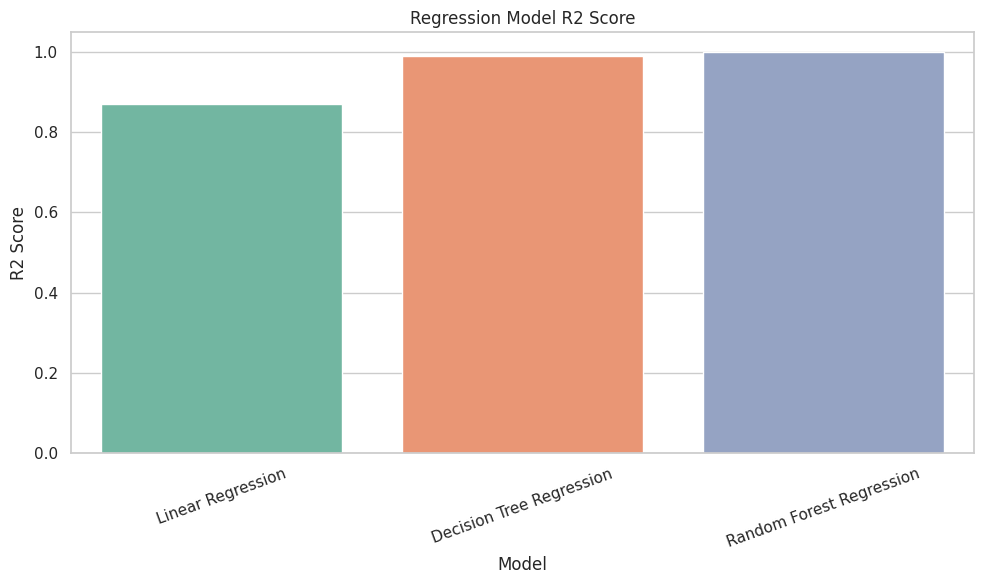



FINAL CLASSIFICATION RESULTS
              Model  Accuracy  ROC_AUC
      Random Forest     0.988 0.999264
      Decision Tree     0.986 0.986000
Logistic Regression     0.983 0.999460


FINAL REGRESSION RESULTS
                   Model        MAE       RMSE  R2 Score
Random Forest Regression  21.849935  32.824638  0.998401
Decision Tree Regression  60.163136  84.570075  0.989385
       Linear Regression 219.824781 296.536612  0.869489


In [12]:
# ============================================================
# COMPLETE MACHINE LEARNING PIPELINE
# Feature Engineering + Classification + ROC + Regression
# Decision Tree + Random Forest + Logistic Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 2. BASIC CLEANING
# ============================================================

# Convert date
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

# Remove rows with missing important values
df = df.dropna(
    subset=[
        "quantity",
        "unit_price",
        "discount",
        "delivery_days",
        "customer_rating",
        "revenue"
    ]
)


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# Date features
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.dayofweek

# Weekend feature
df["is_weekend"] = (
    df["order_weekday"] >= 5
).astype(int)

# Total price before discount
df["gross_amount"] = (
    df["quantity"] * df["unit_price"]
)

# Discount amount
df["discount_amount"] = (
    df["gross_amount"] *
    df["discount"] / 100
)

# Final calculated amount
df["net_amount"] = (
    df["gross_amount"] -
    df["discount_amount"]
)

# Average price per quantity
df["price_per_unit"] = (
    df["revenue"] / df["quantity"].replace(0, np.nan)
)

# Replace infinite values
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna()

print("\nFeature Engineered Dataset:")
print(df.head())


# ============================================================
# 4. CLASSIFICATION TARGET
# ============================================================

# Median revenue is used as threshold
revenue_threshold = df["revenue"].median()

df["high_revenue"] = (
    df["revenue"] >= revenue_threshold
).astype(int)

print("\nRevenue Threshold:", revenue_threshold)

print("\nClass Distribution:")
print(df["high_revenue"].value_counts())


# ============================================================
# 5. FEATURES FOR CLASSIFICATION
# ============================================================

features = [
    "product_category",
    "region",
    "quantity",
    "unit_price",
    "discount",
    "payment_method",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_weekday",
    "is_weekend",
    "gross_amount",
    "discount_amount"
]

X = df[features]
y = df["high_revenue"]


# ============================================================
# 6. CATEGORICAL + NUMERICAL FEATURES
# ============================================================

categorical_features = [
    "product_category",
    "region",
    "payment_method"
]

numerical_features = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_weekday",
    "is_weekend",
    "gross_amount",
    "discount_amount"
]


# ============================================================
# 7. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(X_test)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

print("Accuracy:",
      round(logistic_accuracy, 4))

print("ROC-AUC:",
      round(logistic_auc, 4))

print(
    classification_report(
        y_test,
        logistic_pred
    )
)


# ============================================================
# 10. DECISION TREE CLASSIFIER
# ============================================================

tree_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

tree_classifier.fit(
    X_train,
    y_train
)

tree_pred = tree_classifier.predict(
    X_test
)

tree_prob = tree_classifier.predict_proba(
    X_test
)[:, 1]

tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_auc = roc_auc_score(
    y_test,
    tree_prob
)

print("\n==============================")
print("DECISION TREE")
print("==============================")

print("Accuracy:",
      round(tree_accuracy, 4))

print("ROC-AUC:",
      round(tree_auc, 4))


# ============================================================
# 11. RANDOM FOREST CLASSIFIER
# ============================================================

forest_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_classifier.fit(
    X_train,
    y_train
)

forest_pred = forest_classifier.predict(
    X_test
)

forest_prob = forest_classifier.predict_proba(
    X_test
)[:, 1]

forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)

forest_auc = roc_auc_score(
    y_test,
    forest_prob
)

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

print("Accuracy:",
      round(forest_accuracy, 4))

print("ROC-AUC:",
      round(forest_auc, 4))


# ============================================================
# 12. ACCURACY COMPARISON
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "ROC_AUC": [
        logistic_auc,
        tree_auc,
        forest_auc
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(
    model_results.sort_values(
        "Accuracy",
        ascending=False
    )
)


# ============================================================
# 13. ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="husl",
    legend=False
)

plt.title("Classification Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(
    model_results["Accuracy"]
):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

cm = confusion_matrix(
    y_test,
    forest_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=[
        "Low Revenue",
        "High Revenue"
    ],
    yticklabels=[
        "Low Revenue",
        "High Revenue"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 15. ROC CURVE
# ============================================================

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_prob
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob
)

fpr_forest, tpr_forest, _ = roc_curve(
    y_test,
    forest_prob
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression AUC = {logistic_auc:.3f}",
    linewidth=2
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree AUC = {tree_auc:.3f}",
    linewidth=2
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest AUC = {forest_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 16. REGRESSION
# ============================================================

# IMPORTANT:
# For regression, target = actual revenue

regression_features = [
    "product_category",
    "region",
    "quantity",
    "unit_price",
    "discount",
    "payment_method",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_weekday",
    "is_weekend"
]

X_reg = df[regression_features]
y_reg = df["revenue"]


reg_categorical = [
    "product_category",
    "region",
    "payment_method"
]

reg_numerical = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_weekday",
    "is_weekend"
]


reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            reg_numerical
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            reg_categorical
        )
    ]
)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 17. LINEAR REGRESSION
# ============================================================

linear_regression = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_regression.fit(
    X_train_reg,
    y_train_reg
)

linear_pred = linear_regression.predict(
    X_test_reg
)

linear_mae = mean_absolute_error(
    y_test_reg,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test_reg,
    linear_pred
)

print("\n==============================")
print("LINEAR REGRESSION")
print("==============================")

print("MAE:",
      round(linear_mae, 2))

print("RMSE:",
      round(linear_rmse, 2))

print("R2 Score:",
      round(linear_r2, 4))


# ============================================================
# 18. DECISION TREE REGRESSION
# ============================================================

tree_regression = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

tree_regression.fit(
    X_train_reg,
    y_train_reg
)

tree_reg_pred = tree_regression.predict(
    X_test_reg
)

tree_reg_r2 = r2_score(
    y_test_reg,
    tree_reg_pred
)

tree_reg_mae = mean_absolute_error(
    y_test_reg,
    tree_reg_pred
)

tree_reg_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        tree_reg_pred
    )
)

print("\n==============================")
print("DECISION TREE REGRESSION")
print("==============================")

print("MAE:",
      round(tree_reg_mae, 2))

print("RMSE:",
      round(tree_reg_rmse, 2))

print("R2 Score:",
      round(tree_reg_r2, 4))


# ============================================================
# 19. RANDOM FOREST REGRESSION
# ============================================================

forest_regression = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_regression.fit(
    X_train_reg,
    y_train_reg
)

forest_reg_pred = forest_regression.predict(
    X_test_reg
)

forest_reg_r2 = r2_score(
    y_test_reg,
    forest_reg_pred
)

forest_reg_mae = mean_absolute_error(
    y_test_reg,
    forest_reg_pred
)

forest_reg_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        forest_reg_pred
    )
)

print("\n==============================")
print("RANDOM FOREST REGRESSION")
print("==============================")

print("MAE:",
      round(forest_reg_mae, 2))

print("RMSE:",
      round(forest_reg_rmse, 2))

print("R2 Score:",
      round(forest_reg_r2, 4))


# ============================================================
# 20. REGRESSION MODEL COMPARISON
# ============================================================

reg_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        tree_reg_mae,
        forest_reg_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_reg_rmse,
        forest_reg_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_reg_r2,
        forest_reg_r2
    ]
})

print("\n==============================")
print("REGRESSION MODEL COMPARISON")
print("==============================")

print(
    reg_results.sort_values(
        "R2 Score",
        ascending=False
    )
)


# ============================================================
# 21. ACTUAL VS PREDICTED REVENUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test_reg,
    y=forest_reg_pred,
    color="purple",
    alpha=0.7
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title(
    "Actual vs Predicted Revenue - Random Forest"
)

# Perfect prediction line
min_value = min(
    y_test_reg.min(),
    forest_reg_pred.min()
)

max_value = max(
    y_test_reg.max(),
    forest_reg_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. REGRESSION R2 COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=reg_results,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Regression Model R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


# ============================================================
# 23. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("FINAL CLASSIFICATION RESULTS")
print("=" * 60)

print(
    model_results.sort_values(
        "Accuracy",
        ascending=False
    ).to_string(index=False)
)

print("\n")
print("=" * 60)
print("FINAL REGRESSION RESULTS")
print("=" * 60)

print(
    reg_results.sort_values(
        "R2 Score",
        ascending=False
    ).to_string(index=False)
)

## Thanks..........Please Upvote